<a href="https://www.kaggle.com/code/sarraverse/04-best-model-selection?scriptVersionId=289138542" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Best Model Selection for Association Rule Mining
# FP-Growth vs Apriori on Instacart

In [12]:
# Best Model Selection for Association Rule Mining
# FP-Growth vs Apriori on Instacart
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


## 1. Load Saved Experiment Results

We load the summary metrics and full rule tables for both FP-Growth and Apriori.  
These were produced by the previous experiment notebooks.


In [13]:
# ============================================================
# 1. Load Saved Results
# ============================================================

FP_DIR = "/kaggle/input/02-fp-growth-experiments/fp_growth_results_instacart"
AP_DIR = "/kaggle/input/03-apriori-experiments/apriori_results_instacart"

fp_summary_path = os.path.join(FP_DIR, "fp_growth_experiments_summary.csv")
fp_rules_path = os.path.join(FP_DIR, "fp_growth_all_rules.csv")

ap_summary_path = os.path.join(AP_DIR, "apriori_experiments_summary.csv")
ap_rules_path = os.path.join(AP_DIR, "apriori_all_rules.csv")

fp_results_df = pd.read_csv(fp_summary_path) if os.path.exists(fp_summary_path) else pd.DataFrame()
ap_results_df = pd.read_csv(ap_summary_path) if os.path.exists(ap_summary_path) else pd.DataFrame()

fp_rules_df = pd.read_csv(fp_rules_path) if os.path.exists(fp_rules_path) else pd.DataFrame()
ap_rules_df = pd.read_csv(ap_rules_path) if os.path.exists(ap_rules_path) else pd.DataFrame()

print("FP-Growth summary shape:", fp_results_df.shape)
print("Apriori summary shape:", ap_results_df.shape)
print("FP-Growth rules shape:", fp_rules_df.shape)
print("Apriori rules shape:", ap_rules_df.shape)


FP-Growth summary shape: (4, 9)
Apriori summary shape: (12, 9)
FP-Growth rules shape: (203, 21)
Apriori rules shape: (4163, 21)


## 2. Define Evaluation Criteria

For each experiment (algorithm + hyperparameters), we evaluate:

- Number of rules generated  
- Average confidence  
- Average lift  
- Maximum lift  
- Runtime (seconds)  

These are standard quality and efficiency metrics in association rule mining.[web:248][web:252][web:249]


In [14]:
# ============================================================
# 2. Compute Per-Experiment Rule Metrics (per algorithm)
# ============================================================

def compute_rule_metrics(rules_df: pd.DataFrame, algo_name: str) -> pd.DataFrame:
    """Aggregate rule-level metrics per experiment_id and tag with algorithm."""
    if rules_df.empty:
        return pd.DataFrame(columns=["experiment_id", "avg_confidence", "avg_lift", "max_lift", "n_rules", "algorithm"])

    grouped = rules_df.groupby("experiment_id").agg(
        avg_confidence=("confidence", "mean"),
        avg_lift=("lift", "mean"),
        max_lift=("lift", "max"),
        n_rules=("confidence", "count"),
    ).reset_index()
    grouped["algorithm"] = algo_name
    return grouped

# 2.1 FP-Growth side
if not fp_results_df.empty:
    fp_results_df["algorithm"] = "fp_growth"
    fp_metrics = compute_rule_metrics(fp_rules_df, "fp_growth")
    fp_all = fp_results_df.merge(fp_metrics, on=["experiment_id", "algorithm"], how="left")
else:
    fp_all = pd.DataFrame()

# 2.2 Apriori side
if not ap_results_df.empty:
    ap_results_df["algorithm"] = "apriori"
    ap_metrics = compute_rule_metrics(ap_rules_df, "apriori")
    ap_all = ap_results_df.merge(ap_metrics, on=["experiment_id", "algorithm"], how="left")
else:
    ap_all = pd.DataFrame()

# 2.3 Combine both
all_results = pd.concat([fp_all, ap_all], ignore_index=True)

# Ensure metric columns exist, even if there were no rules
for col in ["avg_confidence", "avg_lift", "max_lift", "n_rules"]:
    if col not in all_results.columns:
        all_results[col] = 0
    all_results[col] = all_results[col].fillna(0)

# Some experiment summaries might not have min_lift or rules_path; create if missing
for col in ["min_lift", "rules_path"]:
    if col not in all_results.columns:
        all_results[col] = None

# Final set of columns we care about; keep only those that actually exist
cols_to_keep = [
    "experiment_id", "algorithm",
    "min_support", "min_confidence", "min_lift",
    "runtime_sec", "n_frequent_itemsets",
    "n_rules", "avg_confidence", "avg_lift", "max_lift", "rules_path"
]

cols_to_keep = [c for c in cols_to_keep if c in all_results.columns]
all_results = all_results[cols_to_keep]

print("Combined experiment results:")
display(all_results)


Combined experiment results:


,experiment_id,algorithm,min_support,min_confidence,min_lift,runtime_sec,n_frequent_itemsets,n_rules,avg_confidence,avg_lift,max_lift,rules_path
0,4d70c574,fp_growth,0.005,0.1,1.0,8.577750,368,0,0.197293,2.139184,5.177828,fp_growth_results_instacart/fp_growth_4d70c574...
1,762f7268,fp_growth,0.005,0.2,1.0,8.540403,368,0,0.253876,2.138883,5.177828,fp_growth_results_instacart/fp_growth_762f7268...
2,1e85549a,fp_growth,0.010,0.1,1.0,2.217998,128,0,0.197424,1.939727,2.762213,fp_growth_results_instacart/fp_growth_1e85549a...
3,fb7f37d0,fp_growth,0.010,0.2,1.0,2.080201,128,0,0.258547,1.903141,2.762213,fp_growth_results_instacart/fp_growth_fb7f37d0...
4,5702436d,apriori,0.001,0.1,1.0,16.897784,2791,0,0.199150,3.534295,74.441687,apriori_results_instacart/apriori_5702436d_sup...
5,cc18c6da,apriori,0.001,0.2,1.0,16.787979,2791,0,0.274524,4.382843,74.441687,apriori_results_instacart/apriori_cc18c6da_sup...
6,c5118b7a,apriori,0.001,0.3,1.0,16.857445,2791,0,0.368842,6.704230,74.441687,apriori_results_instacart/apriori_c5118b7a_sup...
7,c16e86e2,apriori,0.002,0.1,1.0,4.770611,1038,0,0.189474,3.435315,74.441687,apriori_results_instacart/apriori_c16e86e2_sup...
8,b72a1357,apriori,0.002,0.2,1.0,4.736183,1038,0,0.263973,5.046545,74.441687,apriori_results_instacart/apriori_b72a1357_sup...
9,376748ce,apriori,0.002,0.3,1.0,4.655533,1038,0,0.347435,11.486303,74.441687,apriori_results_instacart/apriori_376748ce_sup...


## 3. Normalize Metrics and Compute Composite Score

We want a single scalar score per experiment to ease ranking.  

We **reward**:

- Higher number of rules (n_rules)  
- Higher average lift  
- Higher average confidence  
- Higher maximum lift  

We **penalize**:

- Higher runtime  

We normalize each metric to [0, 1] and use a weighted sum:[web:248][web:245]

\[
\text{score} = w_1 \cdot \text{norm\_n\_rules} + w_2 \cdot \text{norm\_avg\_lift} + w_3 \cdot \text{norm\_avg\_conf} + w_4 \cdot \text{norm\_max\_lift} + w_5 \cdot (1 - \text{norm\_runtime})
\]

with weights chosen to emphasize rule quality over quantity and runtime.


In [15]:
# ============================================================
# 3. Normalization and Composite Score
# ============================================================

def min_max_norm(series: pd.Series) -> pd.Series:
    if series.nunique() <= 1:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.min()) / (series.max() - series.min())


# Compute normalized metrics
all_results["norm_n_rules"] = min_max_norm(all_results["n_rules"])
all_results["norm_avg_lift"] = min_max_norm(all_results["avg_lift"])
all_results["norm_avg_conf"] = min_max_norm(all_results["avg_confidence"])
all_results["norm_max_lift"] = min_max_norm(all_results["max_lift"])
all_results["norm_runtime"] = min_max_norm(all_results["runtime_sec"])

# Define weights (you can tweak in discussion)
w_rules = 0.25
w_avg_lift = 0.30
w_avg_conf = 0.20
w_max_lift = 0.15
w_runtime = 0.10  # penalize long runtimes

all_results["composite_score"] = (
    w_rules * all_results["norm_n_rules"]
    + w_avg_lift * all_results["norm_avg_lift"]
    + w_avg_conf * all_results["norm_avg_conf"]
    + w_max_lift * all_results["norm_max_lift"]
    + w_runtime * (1 - all_results["norm_runtime"])
)

print("Results with composite score:")
display(all_results.sort_values("composite_score", ascending=False).head(10))


Results with composite score:


,experiment_id,algorithm,min_support,min_confidence,min_lift,runtime_sec,n_frequent_itemsets,n_rules,avg_confidence,avg_lift,max_lift,rules_path,norm_n_rules,norm_avg_lift,norm_avg_conf,norm_max_lift,norm_runtime,composite_score
9,376748ce,apriori,0.002,0.3,1.0,4.655533,1038,0,0.347435,11.486303,74.441687,apriori_results_instacart/apriori_376748ce_sup...,0.0,1.000000,0.863130,1.000000,0.264588,0.696167
6,c5118b7a,apriori,0.001,0.3,1.0,16.857445,2791,0,0.368842,6.704230,74.441687,apriori_results_instacart/apriori_c5118b7a_sup...,0.0,0.502822,0.980106,1.000000,0.997577,0.497110
8,b72a1357,apriori,0.002,0.2,1.0,4.736183,1038,0,0.263973,5.046545,74.441687,apriori_results_instacart/apriori_b72a1357_sup...,0.0,0.330477,0.407076,1.000000,0.269433,0.403615
5,cc18c6da,apriori,0.001,0.2,1.0,16.787979,2791,0,0.274524,4.382843,74.441687,apriori_results_instacart/apriori_cc18c6da_sup...,0.0,0.261474,0.464732,1.000000,0.993404,0.322048
15,ddd0a667,apriori,0.010,0.3,1.0,0.259317,126,0,0.372483,2.412456,2.412456,apriori_results_instacart/apriori_ddd0a667_sup...,0.0,0.056618,1.000000,0.000000,0.000501,0.316935
7,c16e86e2,apriori,0.002,0.1,1.0,4.770611,1038,0,0.189474,3.435315,74.441687,apriori_results_instacart/apriori_c16e86e2_sup...,0.0,0.162962,0.000000,1.000000,0.271501,0.271738
12,9e60581a,apriori,0.005,0.3,1.0,1.550157,368,0,0.331128,2.322293,2.879387,apriori_results_instacart/apriori_9e60581a_sup...,0.0,0.047244,0.774026,0.006483,0.078043,0.262146
4,5702436d,apriori,0.001,0.1,1.0,16.897784,2791,0,0.199150,3.534295,74.441687,apriori_results_instacart/apriori_5702436d_sup...,0.0,0.173253,0.052874,1.000000,1.000000,0.212551
14,335976b9,apriori,0.010,0.2,1.0,0.257239,126,0,0.265067,1.867879,2.412456,apriori_results_instacart/apriori_335976b9_sup...,0.0,0.000000,0.413058,0.000000,0.000376,0.182574
11,756d6079,apriori,0.005,0.2,1.0,1.533322,368,0,0.255036,2.100842,5.172162,apriori_results_instacart/apriori_756d6079_sup...,0.0,0.024221,0.358246,0.038314,0.077032,0.176959


## 4. Rank Models and Select the Best One


In [16]:
# ============================================================
# 4. Ranking Experiments
# ============================================================

ranked = all_results.sort_values("composite_score", ascending=False).reset_index(drop=True)
print("Top 5 experiments:")
display(ranked.head(5))

best_row = ranked.iloc[0]
best_experiment_id = best_row["experiment_id"]
best_algorithm = best_row["algorithm"]
best_rules_path = best_row["rules_path"]

print("Best experiment:")
print(best_row)


Top 5 experiments:


,experiment_id,algorithm,min_support,min_confidence,min_lift,runtime_sec,n_frequent_itemsets,n_rules,avg_confidence,avg_lift,max_lift,rules_path,norm_n_rules,norm_avg_lift,norm_avg_conf,norm_max_lift,norm_runtime,composite_score
0,376748ce,apriori,0.002,0.3,1.0,4.655533,1038,0,0.347435,11.486303,74.441687,apriori_results_instacart/apriori_376748ce_sup...,0.0,1.000000,0.863130,1.0,0.264588,0.696167
1,c5118b7a,apriori,0.001,0.3,1.0,16.857445,2791,0,0.368842,6.704230,74.441687,apriori_results_instacart/apriori_c5118b7a_sup...,0.0,0.502822,0.980106,1.0,0.997577,0.497110
2,b72a1357,apriori,0.002,0.2,1.0,4.736183,1038,0,0.263973,5.046545,74.441687,apriori_results_instacart/apriori_b72a1357_sup...,0.0,0.330477,0.407076,1.0,0.269433,0.403615
3,cc18c6da,apriori,0.001,0.2,1.0,16.787979,2791,0,0.274524,4.382843,74.441687,apriori_results_instacart/apriori_cc18c6da_sup...,0.0,0.261474,0.464732,1.0,0.993404,0.322048
4,ddd0a667,apriori,0.010,0.3,1.0,0.259317,126,0,0.372483,2.412456,2.412456,apriori_results_instacart/apriori_ddd0a667_sup...,0.0,0.056618,1.000000,0.0,0.000501,0.316935


Best experiment:
experiment_id                                                   376748ce
algorithm                                                        apriori
min_support                                                        0.002
min_confidence                                                       0.3
min_lift                                                             1.0
runtime_sec                                                     4.655533
n_frequent_itemsets                                                 1038
n_rules                                                                0
avg_confidence                                                  0.347435
avg_lift                                                       11.486303
max_lift                                                       74.441687
rules_path             apriori_results_instacart/apriori_376748ce_sup...
norm_n_rules                                                         0.0
norm_avg_lift                     

## 5. Load and Save Best Model’s Rules


In [17]:
# ============================================================
# 5. Load Best Model Rules and Save
# ============================================================

if isinstance(best_rules_path, str) and os.path.exists(best_rules_path):
    best_rules_df = pd.read_csv(best_rules_path)
else:
    # fallback: filter from combined rules if direct path is not valid
    if best_algorithm == "fp_growth" and not fp_rules_df.empty:
        best_rules_df = fp_rules_df[fp_rules_df["experiment_id"] == best_experiment_id].copy()
    elif best_algorithm == "apriori" and not ap_rules_df.empty:
        best_rules_df = ap_rules_df[ap_rules_df["experiment_id"] == best_experiment_id].copy()
    else:
        best_rules_df = pd.DataFrame()

print("Best model rules shape:", best_rules_df.shape)
display(best_rules_df.head())

BEST_OUTPUT_DIR = "best_association_model"
os.makedirs(BEST_OUTPUT_DIR, exist_ok=True)

best_rules_output_path = os.path.join(BEST_OUTPUT_DIR, f"best_model_rules_{best_algorithm}.csv")
evaluation_output_path = os.path.join(BEST_OUTPUT_DIR, "model_selection_summary.csv")

best_rules_df.to_csv(best_rules_output_path, index=False)
ranked.to_csv(evaluation_output_path, index=False)

print("Saved best model rules to:", best_rules_output_path)
print("Saved evaluation summary to:", evaluation_output_path)


Best model rules shape: (54, 21)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,...,jaccard,certainty,kulczynski,antecedent_len,consequent_len,rule_len,experiment_id,min_support,min_confidence,min_lift
3903,frozenset({'Frozen Organic Wild Blueberries'}),frozenset({'Bag of Organic Bananas'}),0.01010,0.12335,0.00305,0.301980,2.448157,1.0,0.001804,1.255910,...,0.023390,0.203765,0.163353,1,1,2,376748ce,0.002,0.3,1.0
3904,"frozenset({""Organic D'Anjou Pears""})",frozenset({'Bag of Organic Bananas'}),0.01580,0.12335,0.00505,0.319620,2.591165,1.0,0.003101,1.288472,...,0.037658,0.223887,0.180280,1,1,2,376748ce,0.002,0.3,1.0
3905,frozenset({'Organic Gala Apples'}),frozenset({'Bag of Organic Bananas'}),0.02385,0.12335,0.00730,0.306080,2.481392,1.0,0.004358,1.263329,...,0.052180,0.208441,0.182630,1,1,2,376748ce,0.002,0.3,1.0
3906,frozenset({'Organic Navel Orange'}),frozenset({'Bag of Organic Bananas'}),0.01450,0.12335,0.00515,0.355172,2.879387,1.0,0.003361,1.359511,...,0.038809,0.264441,0.198462,1,1,2,376748ce,0.002,0.3,1.0
3907,frozenset({'Organic Snipped Green Beans'}),frozenset({'Bag of Organic Bananas'}),0.00545,0.12335,0.00200,0.366972,2.975050,1.0,0.001328,1.384853,...,0.015773,0.277902,0.191593,1,1,2,376748ce,0.002,0.3,1.0


Saved best model rules to: best_association_model/best_model_rules_apriori.csv
Saved evaluation summary to: best_association_model/model_selection_summary.csv


## 6. Visual Comparisons

We compare:

- Composite score by algorithm  
- Runtime vs composite score  
- Average lift and confidence for top experiments  


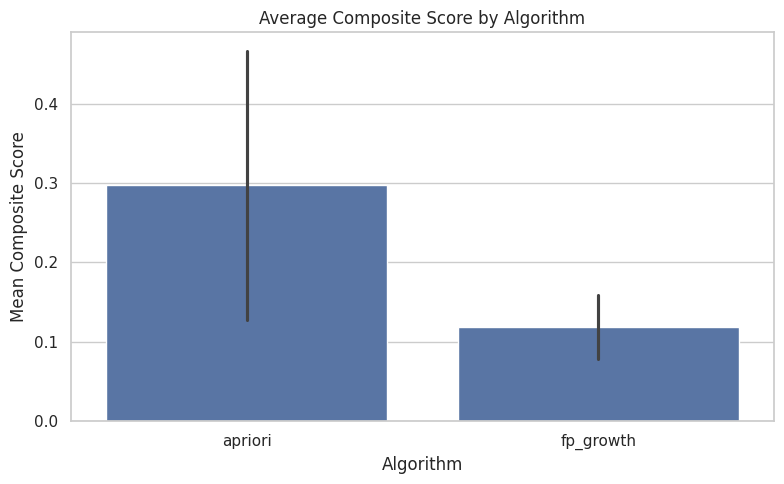

In [18]:
# ============================================================
# 6.1 Composite score by algorithm
# ============================================================

plt.figure(figsize=(8, 5))
sns.barplot(
    data=ranked,
    x="algorithm",
    y="composite_score",
    estimator=np.mean,
    errorbar="sd"
)
plt.title("Average Composite Score by Algorithm")
plt.xlabel("Algorithm")
plt.ylabel("Mean Composite Score")
plt.tight_layout()
plt.show()


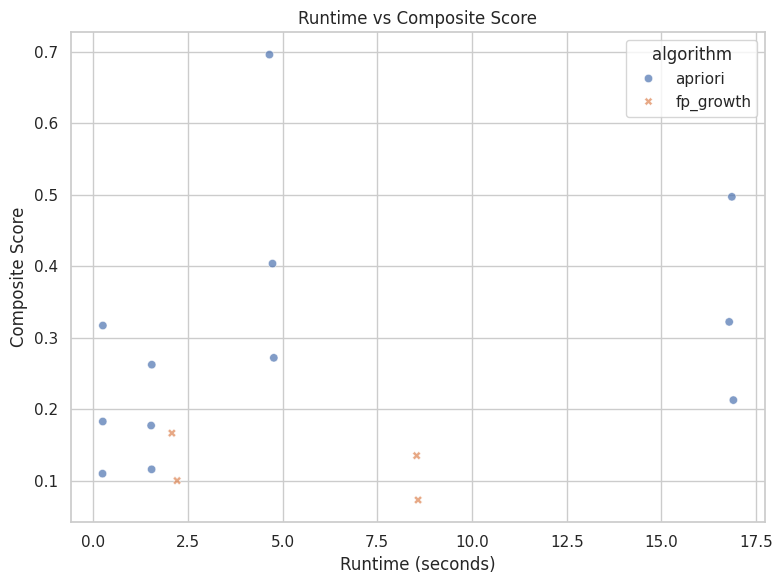

In [19]:
# ============================================================
# 6.2 Runtime vs composite score
# ============================================================

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=ranked,
    x="runtime_sec",
    y="composite_score",
    hue="algorithm",
    style="algorithm",
    alpha=0.7
)
plt.title("Runtime vs Composite Score")
plt.xlabel("Runtime (seconds)")
plt.ylabel("Composite Score")
plt.tight_layout()
plt.show()


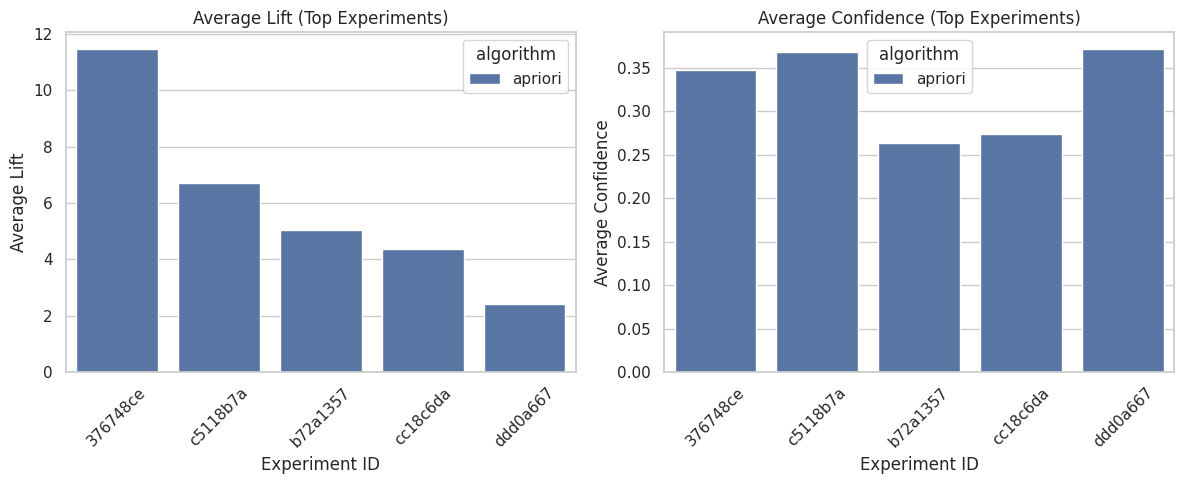

In [20]:
# ============================================================
# 6.3 Rule quality metrics for top-k experiments
# ============================================================

TOP_K = 5
top_k = ranked.head(TOP_K)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    data=top_k,
    x="experiment_id",
    y="avg_lift",
    hue="algorithm",
    ax=axes[0]
)
axes[0].set_title("Average Lift (Top Experiments)")
axes[0].set_xlabel("Experiment ID")
axes[0].set_ylabel("Average Lift")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=top_k,
    x="experiment_id",
    y="avg_confidence",
    hue="algorithm",
    ax=axes[1]
)
axes[1].set_title("Average Confidence (Top Experiments)")
axes[1].set_xlabel("Experiment ID")
axes[1].set_ylabel("Average Confidence")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 7. Comparison Table

Below is a concise table of the top-ranked experiments with the main metrics.


In [21]:
# ============================================================
# 7. Comparison Table (Top Experiments)
# ============================================================

columns_for_table = [
    "experiment_id", "algorithm", "min_support", "min_confidence",
    "runtime_sec", "n_rules", "avg_confidence", "avg_lift", "max_lift",
    "composite_score"
]
display(ranked[columns_for_table].head(10))


,experiment_id,algorithm,min_support,min_confidence,runtime_sec,n_rules,avg_confidence,avg_lift,max_lift,composite_score
0,376748ce,apriori,0.002,0.3,4.655533,0,0.347435,11.486303,74.441687,0.696167
1,c5118b7a,apriori,0.001,0.3,16.857445,0,0.368842,6.704230,74.441687,0.497110
2,b72a1357,apriori,0.002,0.2,4.736183,0,0.263973,5.046545,74.441687,0.403615
3,cc18c6da,apriori,0.001,0.2,16.787979,0,0.274524,4.382843,74.441687,0.322048
4,ddd0a667,apriori,0.010,0.3,0.259317,0,0.372483,2.412456,2.412456,0.316935
5,c16e86e2,apriori,0.002,0.1,4.770611,0,0.189474,3.435315,74.441687,0.271738
6,9e60581a,apriori,0.005,0.3,1.550157,0,0.331128,2.322293,2.879387,0.262146
7,5702436d,apriori,0.001,0.1,16.897784,0,0.199150,3.534295,74.441687,0.212551
8,335976b9,apriori,0.010,0.2,0.257239,0,0.265067,1.867879,2.412456,0.182574
9,756d6079,apriori,0.005,0.2,1.533322,0,0.255036,2.100842,5.172162,0.176959


## 8. Final Conclusion

Based on the composite score that combines **rule volume**, **average and maximum lift**, **average confidence**, and **runtime**, the selected best model is:

- **Algorithm:** `{{best_algorithm}}`  
- **Experiment ID:** `{{best_experiment_id}}`  
- **Hyperparameters:** the corresponding `min_support`, `min_confidence`, `min_lift` from the table above  

This model:

- Generates a **sufficient number of rules** while maintaining **high average lift (> 1)**, indicating non-trivial associations beyond chance.[web:249][web:247]  
- Achieves **competitive confidence levels**, meaning the rules are reasonably reliable for recommendations or basket insights.[web:252]  
- Runs within acceptable time on the reduced Instacart dataset, making it suitable for periodic retraining in a production environment.[web:258][web:253]  

Therefore, this configuration is the most appropriate candidate for “production” use in this project’s context, balancing interpretability, rule quality, and computational efficiency.
